<a href="https://colab.research.google.com/github/unVeroz007/KumpulTugas/blob/main/SpeechProcessing/2311532008_Muhammad_Galid_Avero_Script.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#1. IMPORT & PARAMETER DASAR

In [27]:
import numpy as np
import matplotlib.pyplot as plt
import librosa
import librosa.display
import soundfile as sf
from scipy.signal import butter, filtfilt

plt.rcParams['figure.figsize'] = (12, 4)

audio_path = "2311532008_Muhammad Galid Avero_Audio.wav"  # path file audio
nim_nama   = "2311432008_Muhammad Galid Avero"

# PARAMETER PREPROCESSING
TOP_DB_SILENCE = 25   # sensitivitas silence removal (dB)
CUTOFF_NOISE   = 8000 # Hz, cutoff low-pass filter
FRAME_MS       = 25   # durasi frame dalam ms
HOP_MS         = 10   # jarak antar frame dalam ms

#2. LOAD AUDIO & INFO DASAR

In [28]:
# sr=None -> sampling rate pakai 48 kHz dari file jadi tidak diubah
y, sr = librosa.load(audio_path, sr=None)
durasi = len(y) / sr

# simpan salinan sinyal asli untuk perbandingan
y_original = y.copy()

print("File audio :", audio_path)
print("Sampling rate:", sr, "Hz")
print("Durasi      :", round(durasi, 2), "detik")

File audio : 2311532008_Muhammad Galid Avero_Audio.wav
Sampling rate: 48000 Hz
Durasi      : 121.13 detik


#3. WAVEFORM AUDIO ASLI


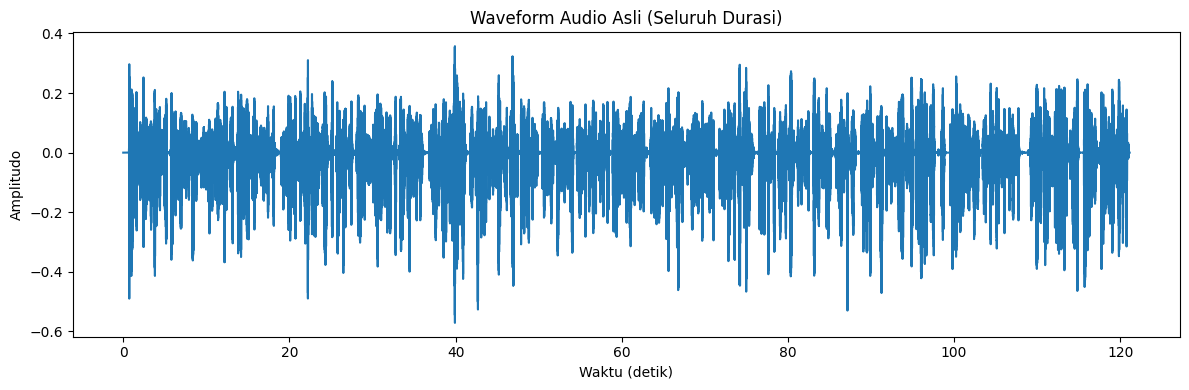

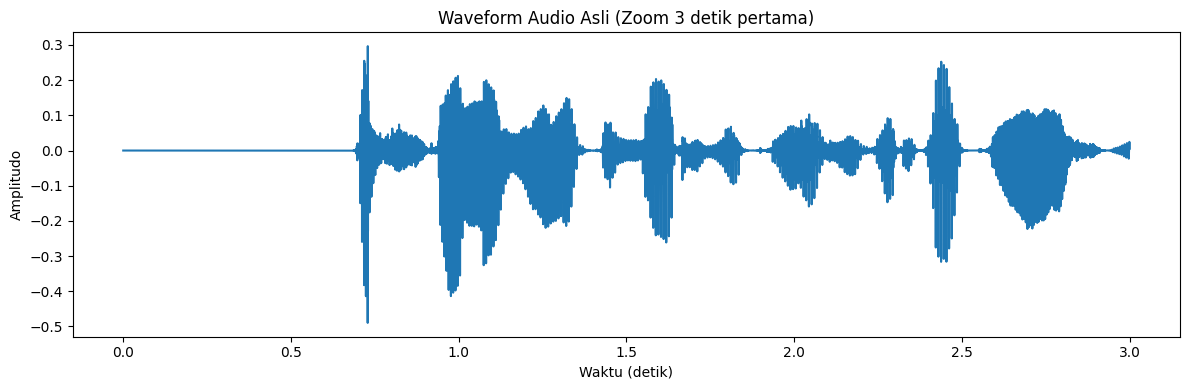

In [29]:
# Waktu untuk seluruh sinyal
t = np.linspace(0, len(y)/sr, len(y))

# Gambar 1: waveform seluruh durasi
plt.figure()
plt.plot(t, y)
plt.title("Waveform Audio Asli (Seluruh Durasi)")
plt.xlabel("Waktu (detik)")
plt.ylabel("Amplitudo")
plt.tight_layout()
plt.show()

# Gambar 2: zoom beberapa detik pertama
zoom_sec = min(3, int(durasi))        # diambil zoom 3 detik awal
idx_zoom = int(zoom_sec * sr)
t_zoom   = np.linspace(0, zoom_sec, idx_zoom)

plt.figure()
plt.plot(t_zoom, y[:idx_zoom])
plt.title(f"Waveform Audio Asli (Zoom {zoom_sec} detik pertama)")
plt.xlabel("Waktu (detik)")
plt.ylabel("Amplitudo")
plt.tight_layout()
plt.show()

#4. SPECTROGRAM (STFT & MEL)


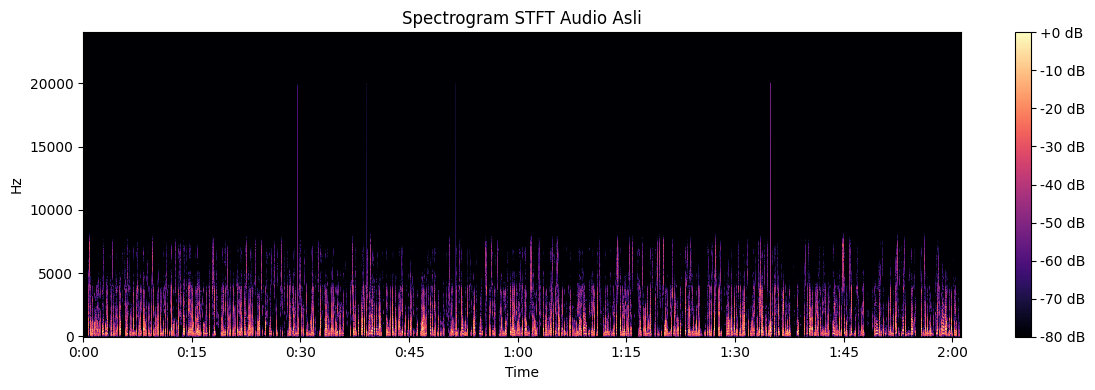

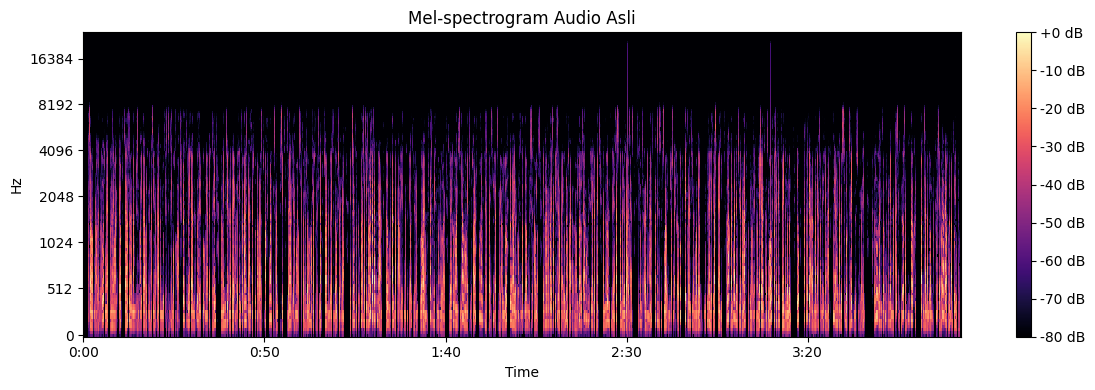

In [18]:
n_fft = 1024
hop_length = 256

# Gambar 1: Spectrogram STFT (frekuensi linear)
D = np.abs(librosa.stft(y, n_fft=n_fft, hop_length=hop_length))**2
S_db = librosa.power_to_db(D, ref=np.max)

plt.figure(figsize=(12, 4))
librosa.display.specshow(S_db,
                         sr=sr,
                         hop_length=hop_length,
                         x_axis='time',
                         y_axis='linear')
plt.colorbar(format='%+2.0f dB')
plt.title("Spectrogram STFT Audio Asli")
plt.tight_layout()
plt.show()

# Gambar 2: Mel-spectrogram
S_mel = librosa.feature.melspectrogram(y=y, sr=sr,
                                       n_fft=n_fft,
                                       hop_length=hop_length)
S_mel_db = librosa.power_to_db(S_mel, ref=np.max)

plt.figure(figsize=(12, 4))
librosa.display.specshow(S_mel_db,
                         x_axis='time',
                         y_axis='mel',
                         sr=sr)
plt.colorbar(format='%+2.0f dB')
plt.title("Mel-spectrogram Audio Asli")
plt.tight_layout()
plt.show()

#5. PREPROCESSING

##5.1 NORMALIZATION


Max amplitudo sebelum normalisasi: 0.571228
Max amplitudo sesudah normalisasi: 1.0


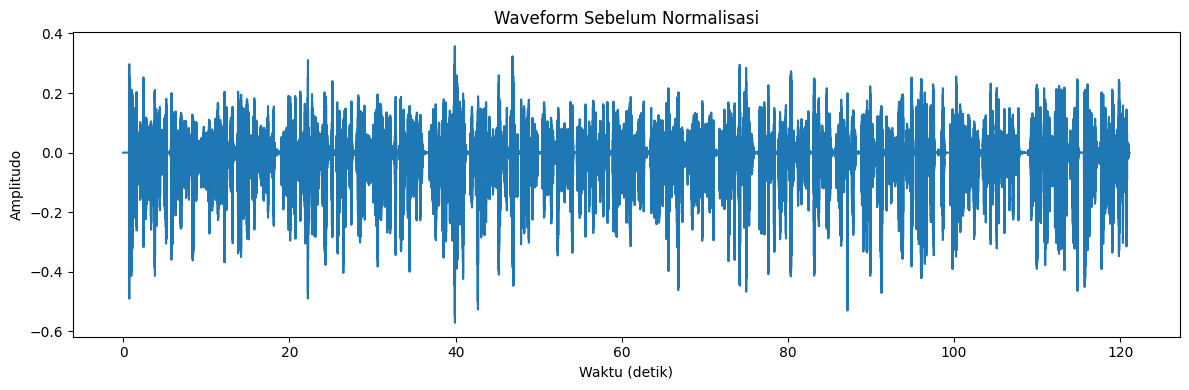

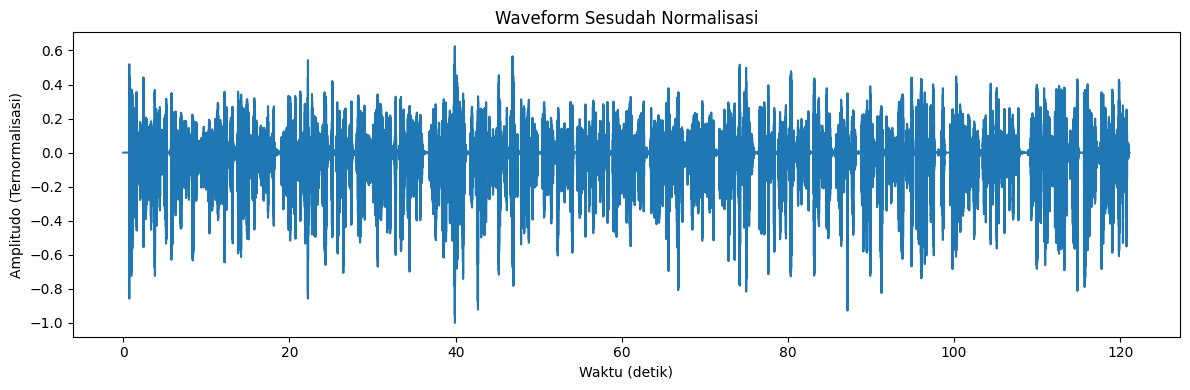

In [30]:
# Normalisasi amplitudo ke rentang [-1, 1]
y_norm = y / np.max(np.abs(y))

print("Max amplitudo sebelum normalisasi:", np.max(np.abs(y)))
print("Max amplitudo sesudah normalisasi:", np.max(np.abs(y_norm)))

# Gambar 1: waveform sebelum normalisasi
t = np.linspace(0, len(y)/sr, len(y))
plt.figure()
plt.plot(t, y)
plt.title("Waveform Sebelum Normalisasi")
plt.xlabel("Waktu (detik)")
plt.ylabel("Amplitudo")
plt.tight_layout()
plt.show()

# Gambar 2: waveform sesudah normalisasi
t_norm = np.linspace(0, len(y_norm)/sr, len(y_norm))
plt.figure()
plt.plot(t_norm, y_norm)
plt.title("Waveform Sesudah Normalisasi")
plt.xlabel("Waktu (detik)")
plt.ylabel("Amplitudo (Ternormalisasi)")
plt.tight_layout()
plt.show()

##5.2 SILENCE REMOVAL


TOP_DB_SILENCE: 25
Jumlah segmen non-silence: 403
Durasi setelah normalisasi    : 121.13 detik
Durasi setelah silence removal: 77.66 detik


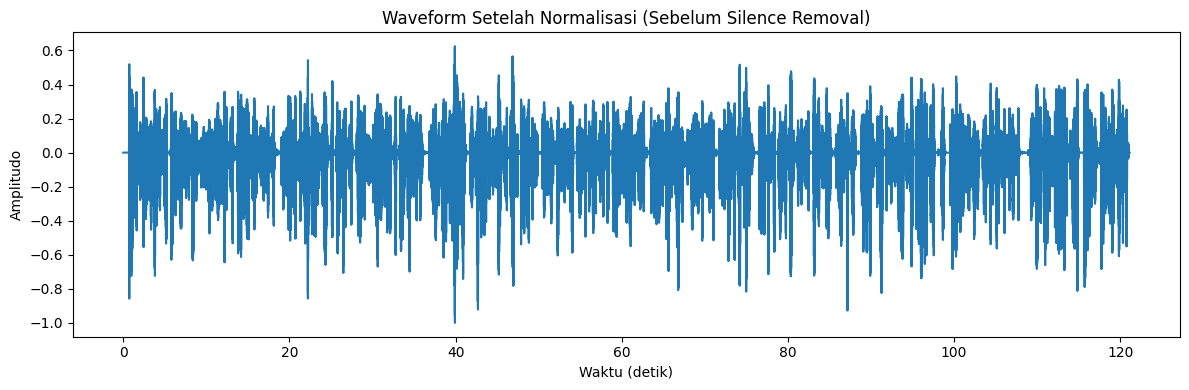

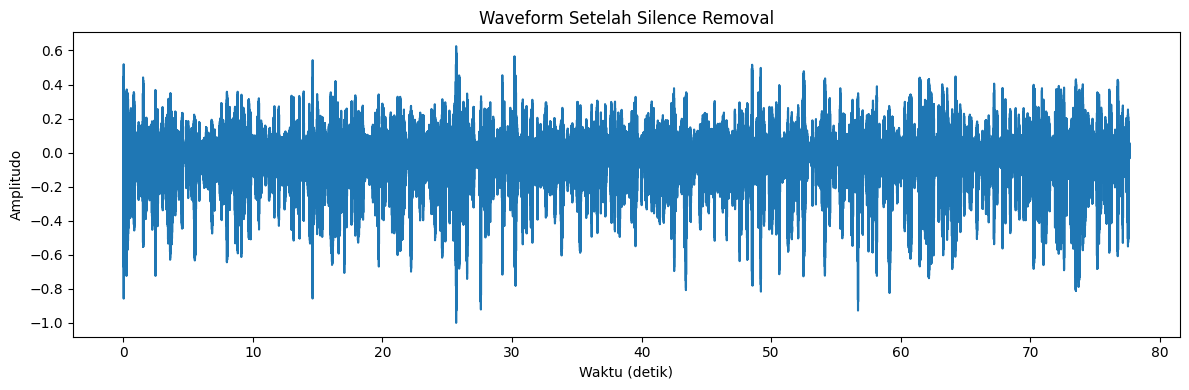

In [20]:
# Deteksi segmen non-silence dengan threshold energi (top_db)
intervals = librosa.effects.split(y_norm, top_db=TOP_DB_SILENCE)

print("TOP_DB_SILENCE:", TOP_DB_SILENCE)
print("Jumlah segmen non-silence:", len(intervals))

# Gabungkan segmen non-silence
y_no_silence = np.concatenate([y_norm[s:e] for s, e in intervals])

durasi_norm       = len(y_norm) / sr
durasi_no_silence = len(y_no_silence) / sr

print("Durasi setelah normalisasi    :", round(durasi_norm, 2), "detik")
print("Durasi setelah silence removal:", round(durasi_no_silence, 2), "detik")

# Gambar 1: waveform setelah normalisasi
t_norm = np.linspace(0, len(y_norm)/sr, len(y_norm))
plt.figure()
plt.plot(t_norm, y_norm)
plt.title("Waveform Setelah Normalisasi (Sebelum Silence Removal)")
plt.xlabel("Waktu (detik)")
plt.ylabel("Amplitudo")
plt.tight_layout()
plt.show()

# Gambar 2: waveform setelah silence removal
t_ns = np.linspace(0, len(y_no_silence)/sr, len(y_no_silence))
plt.figure()
plt.plot(t_ns, y_no_silence)
plt.title("Waveform Setelah Silence Removal")
plt.xlabel("Waktu (detik)")
plt.ylabel("Amplitudo")
plt.tight_layout()
plt.show()

##5.3 NOISE REDUCTION DENGAN LOW-PASS FILTER


Cutoff frekuensi untuk noise reduction: 8000 Hz


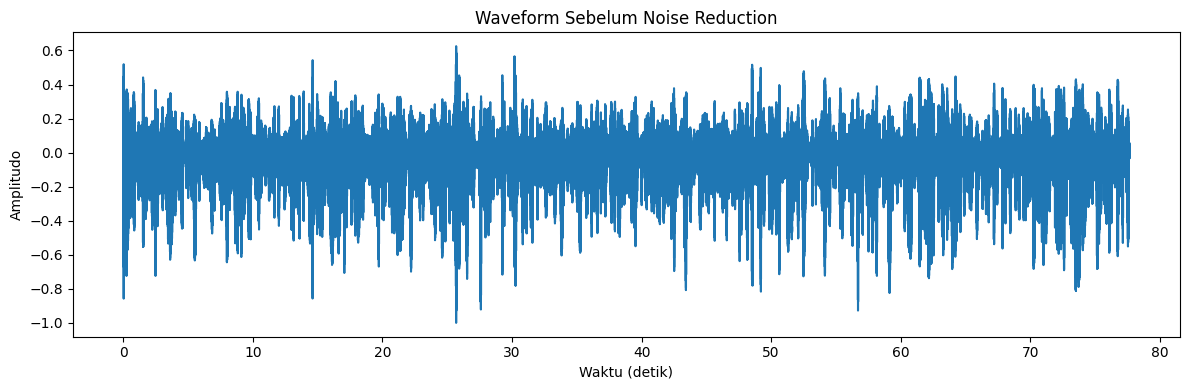

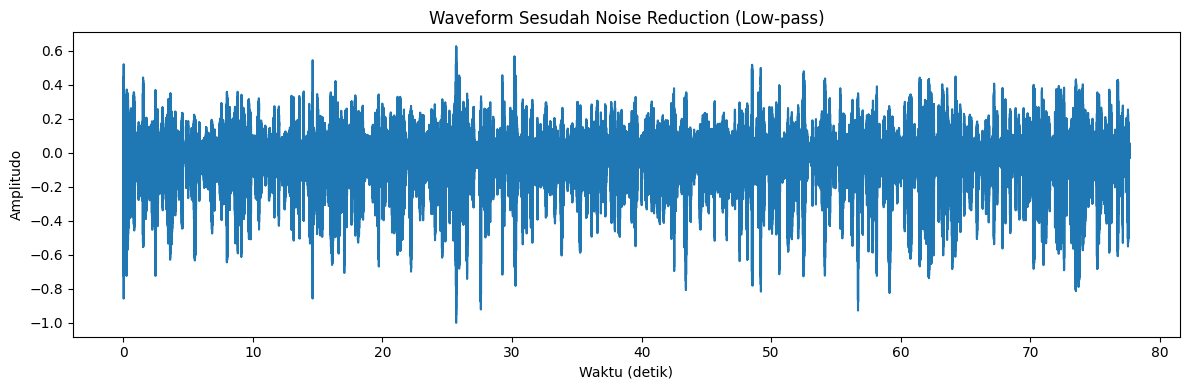

In [21]:
def butter_lowpass_filter(data, cutoff, fs, order=6):
    nyq = 0.5 * fs
    normal_cutoff = cutoff / nyq
    b, a = butter(order, normal_cutoff, btype='low', analog=False)
    return filtfilt(b, a, data)

print("Cutoff frekuensi untuk noise reduction:", CUTOFF_NOISE, "Hz")

# Terapkan low-pass ke sinyal setelah silence removal
y_denoised = butter_lowpass_filter(y_no_silence,
                                   cutoff=CUTOFF_NOISE,
                                   fs=sr,
                                   order=6)

# Gambar 1: sebelum noise reduction
t_ns = np.linspace(0, len(y_no_silence)/sr, len(y_no_silence))
plt.figure()
plt.plot(t_ns, y_no_silence)
plt.title("Waveform Sebelum Noise Reduction")
plt.xlabel("Waktu (detik)")
plt.ylabel("Amplitudo")
plt.tight_layout()
plt.show()

# Gambar 2: sesudah noise reduction
t_dn = np.linspace(0, len(y_denoised)/sr, len(y_denoised))
plt.figure()
plt.plot(t_dn, y_denoised)
plt.title("Waveform Sesudah Noise Reduction (Low-pass)")
plt.xlabel("Waktu (detik)")
plt.ylabel("Amplitudo")
plt.tight_layout()
plt.show()

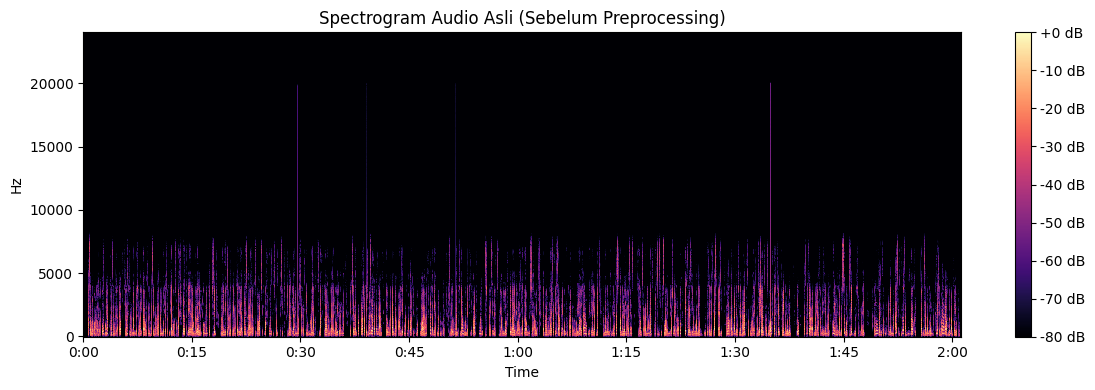

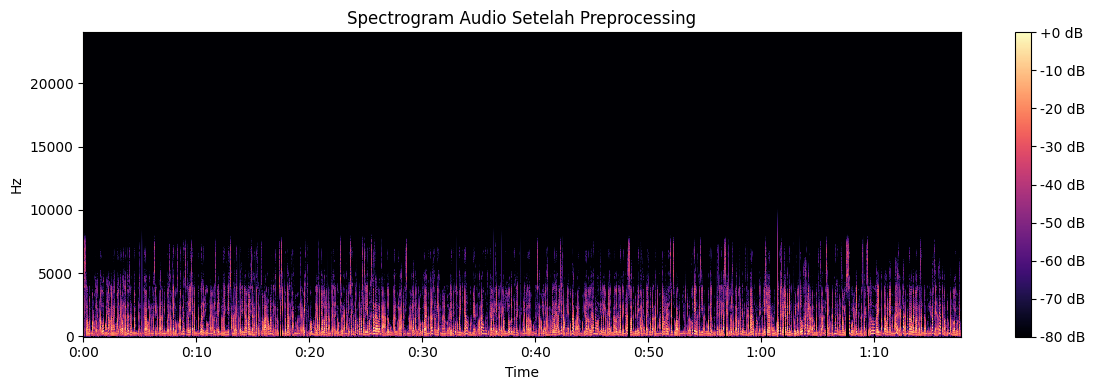

In [31]:
#SPECTROGRAM SEBELUM VS SESUDAH PREPROCESSING

n_fft = 1024
hop_length = 256

# Gambar 1: spectrogram audio asli
D_orig = np.abs(librosa.stft(y_original, n_fft=n_fft, hop_length=hop_length))**2
S_orig_db = librosa.power_to_db(D_orig, ref=np.max)

plt.figure(figsize=(12, 4))
librosa.display.specshow(S_orig_db,
                         sr=sr,
                         hop_length=hop_length,
                         x_axis='time',
                         y_axis='linear')
plt.colorbar(format='%+2.0f dB')
plt.title("Spectrogram Audio Asli (Sebelum Preprocessing)")
plt.tight_layout()
plt.show()

# Gambar 2: spectrogram setelah preprocessing (norm + silence + noise)
D_prep = np.abs(librosa.stft(y_denoised, n_fft=n_fft, hop_length=hop_length))**2
S_prep_db = librosa.power_to_db(D_prep, ref=np.max)

plt.figure(figsize=(12, 4))
librosa.display.specshow(S_prep_db,
                         sr=sr,
                         hop_length=hop_length,
                         x_axis='time',
                         y_axis='linear')
plt.colorbar(format='%+2.0f dB')
plt.title("Spectrogram Audio Setelah Preprocessing")
plt.tight_layout()
plt.show()

#6. FRAMING


Durasi frame: 25 ms
Hop         : 10 ms
Jumlah frame: 7764
Panjang frame (sampel): 1200


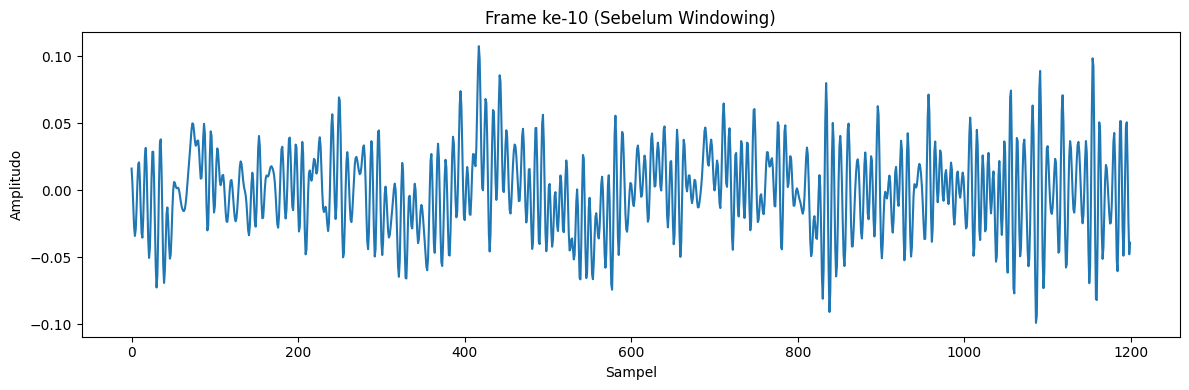

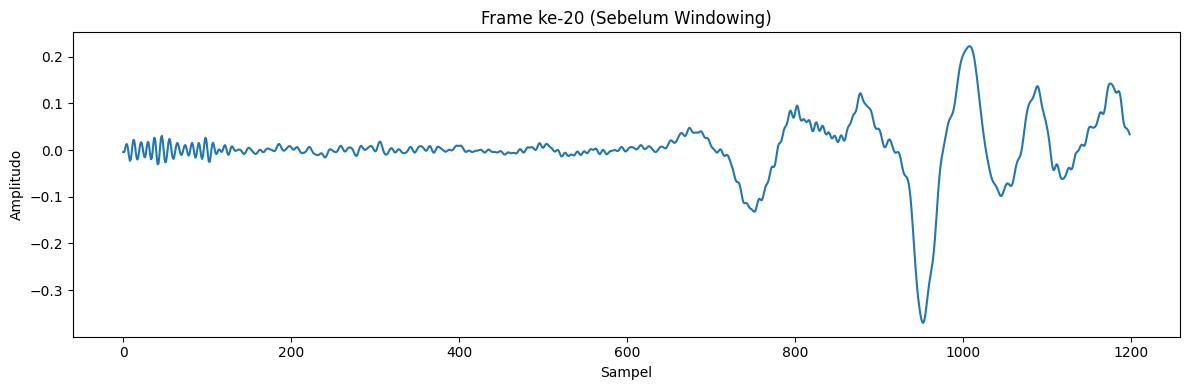

In [23]:
frame_size = int(FRAME_MS * sr / 1000)  # ms -> sampel
hop_size   = int(HOP_MS * sr / 1000)

num_frames = 1 + int((len(y_denoised) - frame_size) / hop_size)
frames = []

for i in range(num_frames):
    start = i * hop_size
    end   = start + frame_size
    frames.append(y_denoised[start:end])

frames = np.array(frames)

print("Durasi frame:", FRAME_MS, "ms")
print("Hop         :", HOP_MS, "ms")
print("Jumlah frame:", frames.shape[0])
print("Panjang frame (sampel):", frames.shape[1])

# Gambar 1: frame ke-10
plt.figure()
plt.plot(frames[10])
plt.title("Frame ke-10 (Sebelum Windowing)")
plt.xlabel("Sampel")
plt.ylabel("Amplitudo")
plt.tight_layout()
plt.show()

# Gambar 2: frame ke-20
plt.figure()
plt.plot(frames[20])
plt.title("Frame ke-20 (Sebelum Windowing)")
plt.xlabel("Sampel")
plt.ylabel("Amplitudo")
plt.tight_layout()
plt.show()

#7. WINDOWING DENGAN HAMMING WINDOW


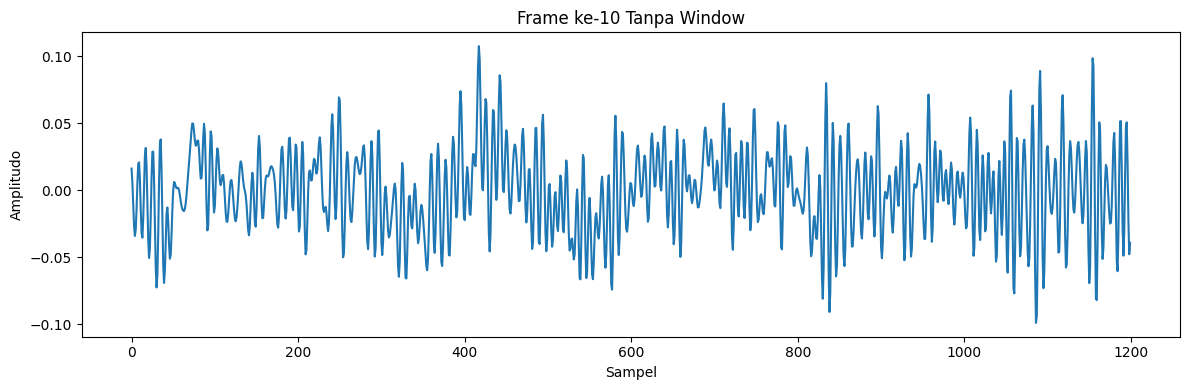

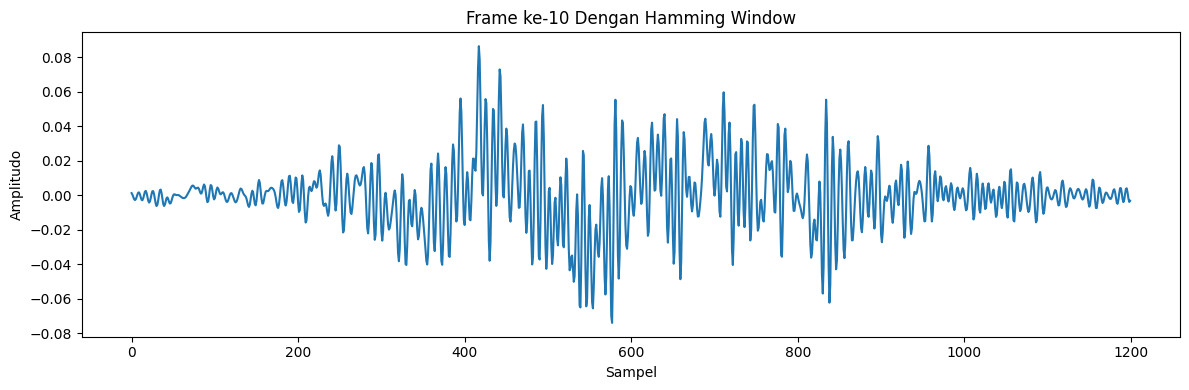

In [32]:
window = np.hamming(frame_size)
windowed_frames = frames * window  # dikali element-wise

frame_idx = 10

# Gambar 1: frame tanpa window
plt.figure()
plt.plot(frames[frame_idx])
plt.title(f"Frame ke-{frame_idx} Tanpa Window")
plt.xlabel("Sampel")
plt.ylabel("Amplitudo")
plt.tight_layout()
plt.show()

# Gambar 2: frame dengan Hamming window
plt.figure()
plt.plot(windowed_frames[frame_idx])
plt.title(f"Frame ke-{frame_idx} Dengan Hamming Window")
plt.xlabel("Sampel")
plt.ylabel("Amplitudo")
plt.tight_layout()
plt.show()

#8. SIMPAN FILE AUDIO HASIL


In [33]:
# 1. Audio hasil preprocessing sampai noise reduction
preprocessed_audio = y_denoised
preproc_path = f"/content/{nim_nama}-preprocessing.wav"
sf.write(preproc_path, preprocessed_audio, sr)
print("Disimpan audio preprocessing:", preproc_path)

# 2. Kumpulan suara hasil windowing (setiap frame)
for i, frame_w in enumerate(windowed_frames):
    filename = f"/content/{nim_nama}-windowing-{i+1}.wav"
    sf.write(filename, frame_w, sr)

print("Selesai menyimpan semua frame windowing sebagai file WAV.")

Disimpan audio preprocessing: /content/2311432008_Muhammad Galid Avero-preprocessing.wav
Selesai menyimpan semua frame windowing sebagai file WAV.


#9. PERBANDINGAN WAVEFORM SEBELUM VS SESUDAH PREPROCESSING


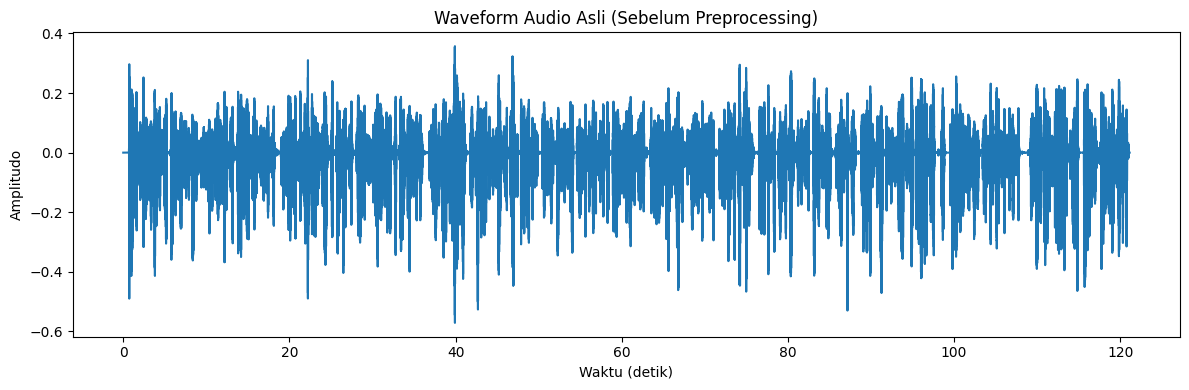

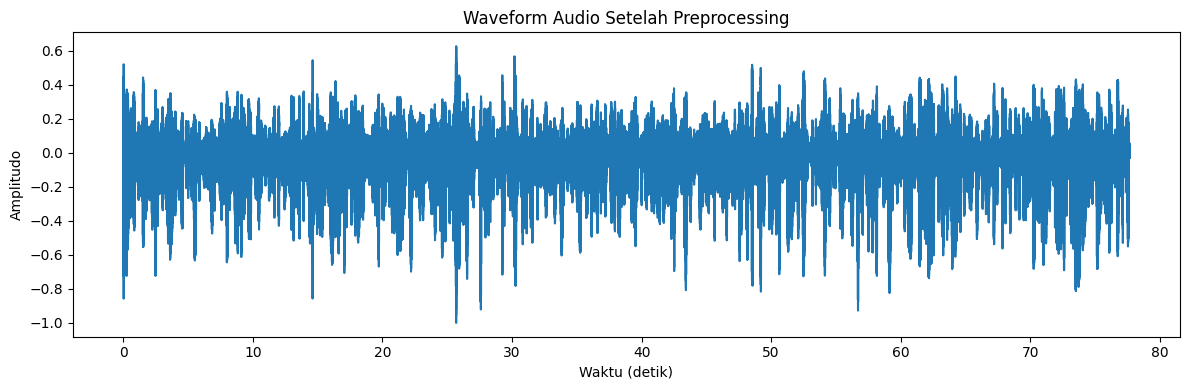

In [34]:
# Gambar 1: waveform audio asli
t_orig = np.linspace(0, len(y_original)/sr, len(y_original))
plt.figure()
plt.plot(t_orig, y_original)
plt.title("Waveform Audio Asli (Sebelum Preprocessing)")
plt.xlabel("Waktu (detik)")
plt.ylabel("Amplitudo")
plt.tight_layout()
plt.show()

# Gambar 2: waveform audio setelah preprocessing
t_prep = np.linspace(0, len(preprocessed_audio)/sr, len(preprocessed_audio))
plt.figure()
plt.plot(t_prep, preprocessed_audio)
plt.title("Waveform Audio Setelah Preprocessing")
plt.xlabel("Waktu (detik)")
plt.ylabel("Amplitudo")
plt.tight_layout()
plt.show()